In [3]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
%matplotlib inline


In [5]:
df_index = pd.read_csv('economic_index.csv')

In [6]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [9]:
#drop unnecessary column
df_index.drop(columns=['Unnamed: 0','year', 'month'], axis = 1, inplace=True)

In [10]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [11]:
#check if null value
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [12]:
#visualization
import seaborn as sns

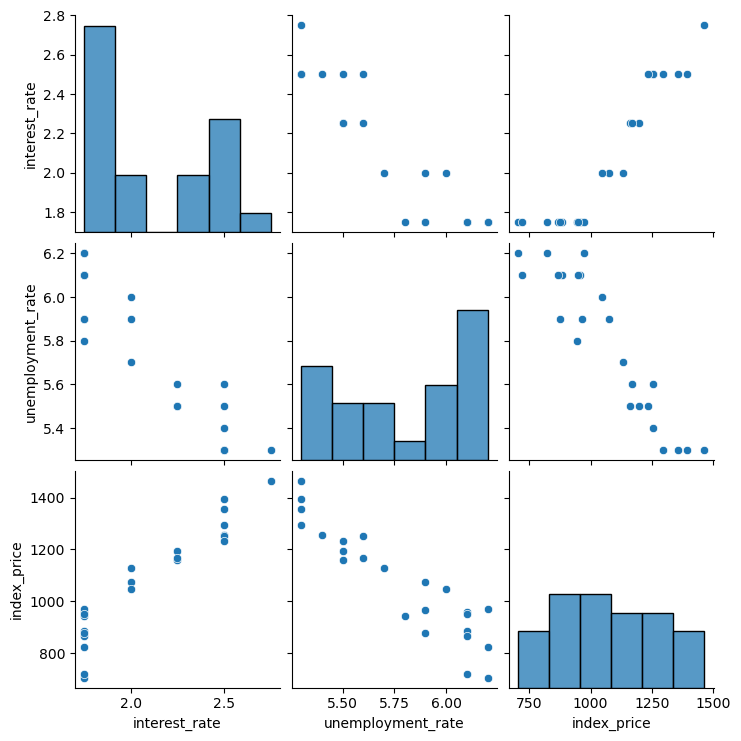

In [15]:
sns.pairplot(df_index)
plt.show()

In [16]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


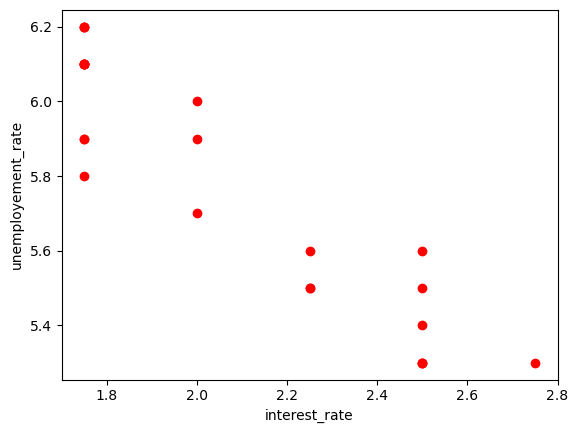

In [19]:
#visualizing datapoints
plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='r')
plt.xlabel('interest_rate')
plt.ylabel('unemployement_rate')
plt.show()

In [28]:
#getting indepemdent and depemdent fetures
x = df_index.iloc[:, :-1]
y = df_index.iloc[:, -1]

In [29]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [30]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [31]:
#train test split
from sklearn.model_selection import train_test_split

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state=42)

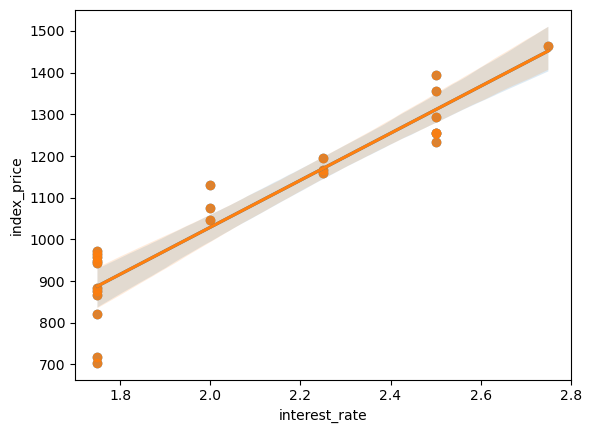

In [38]:
#regplot
import seaborn as sns
sns.regplot(x = df_index['interest_rate'], y = df_index['index_price'])
plt.show()


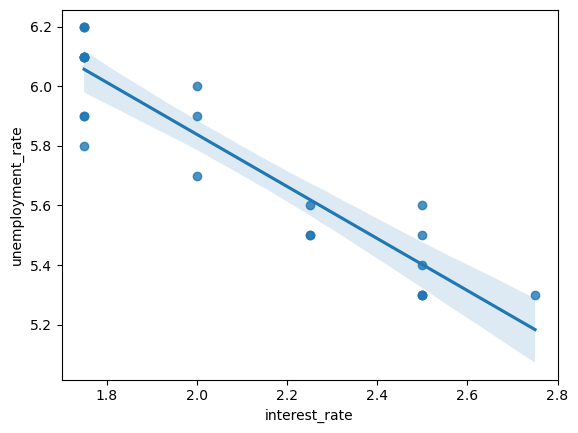

In [39]:
#regplot
import seaborn as sns
sns.regplot(x = df_index['interest_rate'], y = df_index['unemployment_rate'])
plt.show()


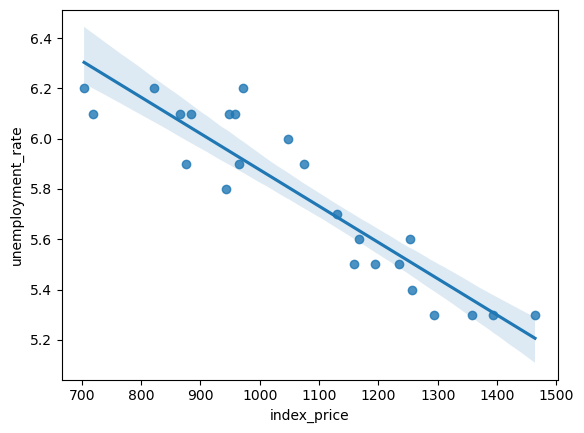

In [41]:
#regplot
import seaborn as sns
sns.regplot(x = df_index['index_price'], y = df_index['unemployment_rate'])
plt.show()


In [42]:
#standardization
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

In [43]:
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

In [44]:
x_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [45]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [46]:
regression.fit(x_train, y_train)

LinearRegression()

In [ ]:
from sklearn.model_selection import cross_val_score
#doing the cross validation
validation_score = cross_val_score(regression, x_train, y_train, scoring='neg_mean_squared_error', cv=3)

In [48]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [49]:
np.mean(validation_score)

np.float64(-5914.828180162388)

In [52]:
#predictio
y_predicted = regression.predict(x_test)

In [53]:
y_predicted

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [54]:
##performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [55]:
mse = mean_squared_error(y_test, y_predicted)
mae = mean_absolute_error(y_test, y_predicted)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5793.762887712579
59.935781523235526
76.11677139574812


In [56]:
from sklearn.metrics import r2_score

In [58]:
score = r2_score(y_test, y_predicted)
print(score)

0.8278978091457142


In [59]:
##adjucted r^2
# Adj R^2 = [(1 - r2) * (n - 1) / (n - k - 1)]
ad_r2 = 1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)
print(ad_r2)

0.713163015242857


#Assumptions

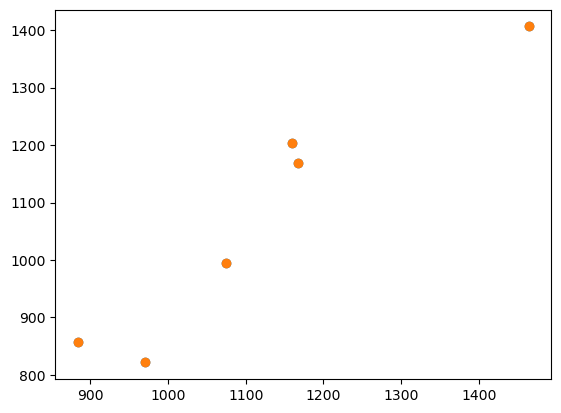

In [61]:
plt.scatter(y_test, y_predicted)
plt.show()

In [62]:
residuals = y_test - y_predicted
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


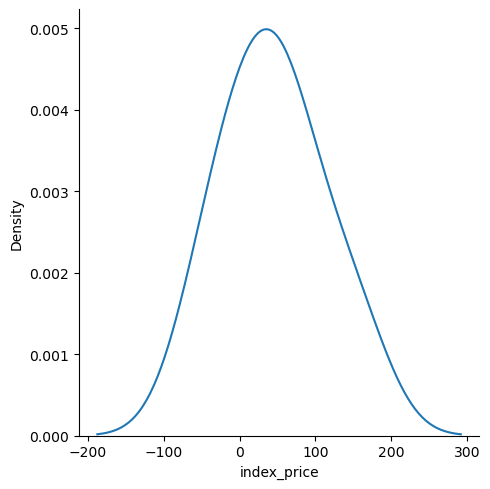

In [63]:
#ploting the residuals
sns.displot(residuals, kind='kde')
plt.show()

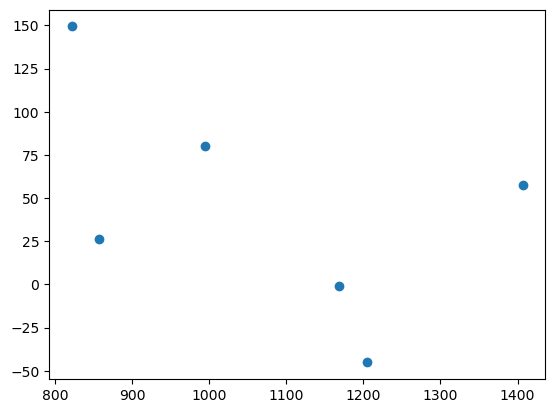

In [65]:
#sctter plot wrt prdiction and residuals
plt.scatter(y_predicted, residuals)
plt.show()

In [67]:
import statsmodels.api as sm
model = sm.OLS(y_train, x_train).fit()

In [68]:
model.summary()

c:\Users\sumit-dev\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Mon, 20 Apr 2026   Prob (F-statistic):                       0.754
Time:                        00:43:12   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [69]:
regression.coef_

array([  88.27275507, -116.25716066])